# Advanced Temporal Pattern Charts (Solution)

Analyze seasonal/time patterns using calendar heatmap-like and lag plots.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "owid_co2_subset.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/owid_co2_subset.csv")

root = resolve_repo_root()
sns.set_theme(style="whitegrid")
df = pd.read_csv(root / "data" / "owid_co2_subset.csv")
# keep country-level rows with key indicators
df = df.dropna(subset=["co2_per_capita", "gdp", "population"]).copy()
d_recent = df[df["year"] >= 2000].copy()
d_latest = d_recent[d_recent["year"] == d_recent["year"].max()].copy()
d_latest.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,coal_co2,energy_per_capita,gas_co2,methane,nitrous_oxide,oil_co2,primary_energy_consumption,temperature_change_from_ghg,trade_co2
32,Afghanistan,2022,AFG,40578847.0,5.330347e+10,10.170,0.251,3.488,1111.573,0.143,16.076,4.419,6.528,45.106,0.001,NaN
67,Albania,2022,ALB,2827614.0,3.617101e+10,4.498,1.591,0.542,9147.205,0.088,2.431,0.864,2.946,25.865,0.000,1.188
102,Algeria,2022,DZA,45477391.0,5.958201e+11,192.779,4.239,0.758,16145.337,101.379,67.576,8.200,61.610,734.248,0.005,NaN
172,Angola,2022,AGO,35635028.0,1.583462e+11,21.089,0.592,NaN,2713.824,1.927,45.564,17.332,14.887,96.707,0.006,NaN
312,Argentina,2022,ARG,45407904.0,8.549144e+11,183.768,4.047,4.731,22049.938,89.620,115.333,50.296,81.967,1001.241,0.016,0.078


## 1) Heatmap year x continent

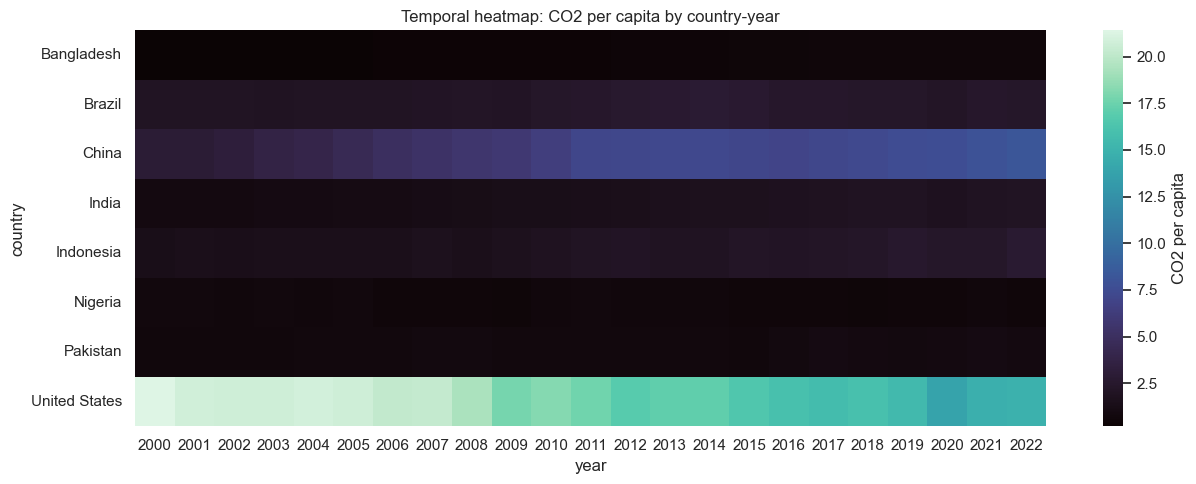

In [2]:
top_countries = (
    d_latest.groupby("country", as_index=False)["population"].mean()
    .nlargest(8, "population")["country"]
)
sub = d_recent[d_recent["country"].isin(top_countries)]
p = sub.pivot_table(index="country", columns="year", values="co2_per_capita", aggfunc="mean")

plt.figure(figsize=(13, 5))
sns.heatmap(p, cmap='mako', cbar_kws={'label':'CO2 per capita'})
plt.title('Temporal heatmap: CO2 per capita by country-year')
plt.tight_layout(); plt.show()

## 2) Seasonal subseries style (group by decade)

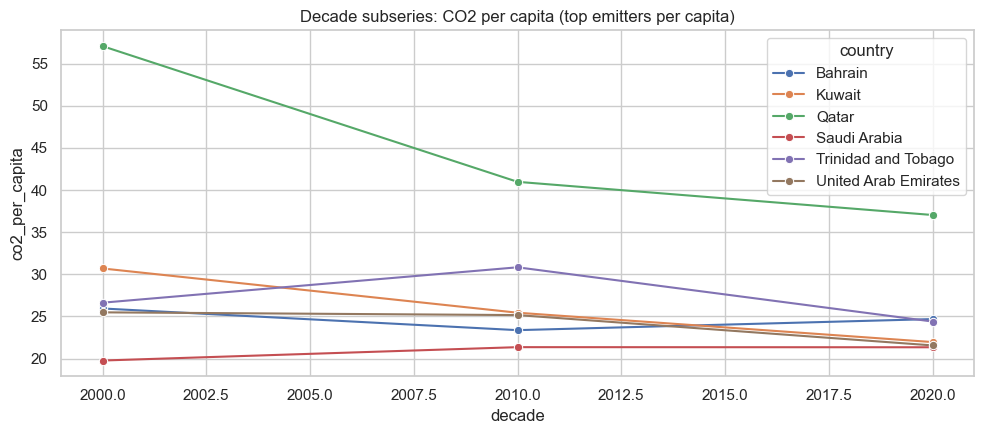

In [3]:
d = d_recent.copy()
d['decade'] = (d['year'] // 10) * 10
s = d.groupby(['decade','country'],as_index=False)['co2_per_capita'].mean()
keep = s.groupby('country', as_index=False)['co2_per_capita'].mean().nlargest(6, 'co2_per_capita')['country']
s = s[s['country'].isin(keep)]
plt.figure(figsize=(10,4.5))
sns.lineplot(data=s, x='decade', y='co2_per_capita', hue='country', marker='o')
plt.title('Decade subseries: CO2 per capita (top emitters per capita)')
plt.tight_layout(); plt.show()

## 3) Lag plot

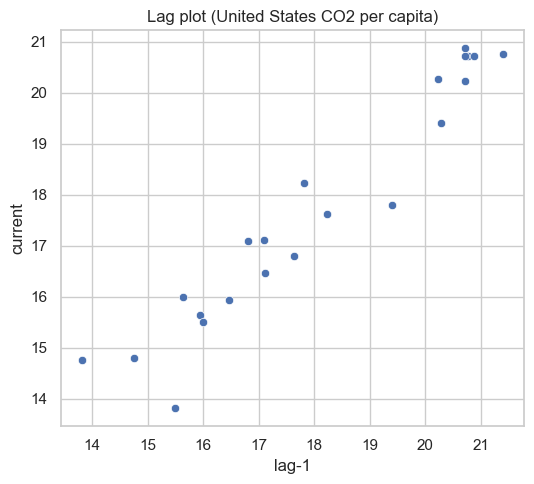

In [4]:
target = 'United States'
us = d_recent[d_recent['country']==target].sort_values('year')[['year','co2_per_capita']].dropna()
us['lag1'] = us['co2_per_capita'].shift(1)

plt.figure(figsize=(5.5,5))
sns.scatterplot(data=us.dropna(), x='lag1', y='co2_per_capita')
plt.title(f'Lag plot ({target} CO2 per capita)')
plt.xlabel('lag-1')
plt.ylabel('current')
plt.tight_layout(); plt.show()

## Reflection
- Nêu 2 điểm học được về chart selection.
- Chỉ ra 1 rủi ro diễn giải sai với loại chart trong lab này.